# Mean Shift Clustering Live Plot Example

I asked chatgpt to help me create an animation showing how Mean Shift Clustering Works! It did a pretty good job. Let's break it down! 

In Mean Shift, each iteration shifts a candidate point (which started as every data point in the dataset) toward the mean of the points within its neighborhood (defined by a kernel, usually a flat or Gaussian kernel with a fixed radius: the bandwidth). Points that end up in the same "mean area" are grouped together.

In other words:
1. For each datapoint, calculate the distance to all other datapoints, and collect all the points that lie within the bandwidth.
2. Find the mean of all the points in the bandwidth.
3. Reassign the mean as a replacement coordinate for the point.
4. Repeat for all points in the dataset. 

5. Using the new "dataset", i.e. all the means, repeat the process until convergence (i.e. when the new means only move slightly or the movement is below a threshold).
6. Assign all the points within a certain tolerance distance as a cluster. (The algorithm would have kept track of where the points started.)

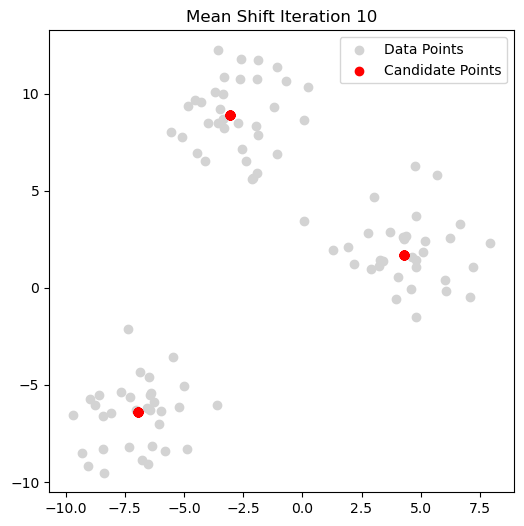

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Generate synthetic data
X, _ = make_blobs(n_samples=100, centers=3, cluster_std=1.75, random_state=42)

# Mean Shift parameters
bandwidth = 2.0
kernel = lambda d: np.exp(-d**2 / (2 * bandwidth**2))  # Gaussian kernel

# Initialize candidate points (same as data points)
candidates = X.copy()
trajectory = [candidates.copy()]  # Store positions for animation

# Run simplified Mean Shift process
for _ in range(10):
    new_candidates = []
    for y in candidates:
        distances = np.linalg.norm(X - y, axis=1)
        weights = kernel(distances)
        weighted_sum = np.sum(weights[:, np.newaxis] * X, axis=0)
        new_y = weighted_sum / np.sum(weights)
        new_candidates.append(new_y)
    candidates = np.array(new_candidates)
    trajectory.append(candidates.copy())

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 6))
scat_data = ax.scatter(X[:, 0], X[:, 1], c='lightgray', label='Data Points')
scat_cands = ax.scatter([], [], c='red', label='Candidate Points')
ax.set_title("Mean Shift Iterations")
ax.legend()
ax.set_xlim(X[:, 0].min()-1, X[:, 0].max()+1)
ax.set_ylim(X[:, 1].min()-1, X[:, 1].max()+1)

# Update function
def update(frame):
    scat_cands.set_offsets(trajectory[frame])
    ax.set_title(f"Mean Shift Iteration {frame}")
    return scat_cands,

# Create animation
ani = FuncAnimation(fig, update, frames=len(trajectory), interval=700, blit=True)

# Display animation in Jupyter
HTML(ani.to_jshtml())
